# **SMART ROOM OCCUPANCY SENSOR**

Load the dataset

In [ ]:
import kagglehub
import os
import shutil

# Download the dataset to KaggleHub's default cache location
kagglehub_cache_path = kagglehub.dataset_download("ananthr1/room-occupancy-estimation-data-set")

# Define the target directory as /content/
target_content_path = "/content/"

# Ensure the target directory exists
os.makedirs(target_content_path, exist_ok=True)

print(f"Dataset downloaded to KaggleHub cache: {kagglehub_cache_path}")
print(f"Copying dataset contents to: {target_content_path}")

# Copy the contents from the KaggleHub cache path to /content/
# Iterate over all items (files and directories) in the kagglehub_cache_path
for item_name in os.listdir(kagglehub_cache_path):
    source_item_path = os.path.join(kagglehub_cache_path, item_name)
    destination_item_path = os.path.join(target_content_path, item_name)

    # If the item already exists in the target_content_path, remove it first to ensure a clean copy
    if os.path.exists(destination_item_path):
        if os.path.isdir(destination_item_path):
            shutil.rmtree(destination_item_path)
        else:
            os.remove(destination_item_path)

    # Use shutil.copy2 instead of shutil.move because the source is a read-only file system
    if os.path.isdir(source_item_path):
        shutil.copytree(source_item_path, destination_item_path)
    else:
        shutil.copy2(source_item_path, destination_item_path)

# Update the 'path' variable to point to the new base directory /content/
path = target_content_path

print(f"Dataset working path updated to: {path}")

100%|██████████| 117k/117k [00:00<00:00, 208kB/s]

Extracting files...
Dataset downloaded to KaggleHub cache: /root/.cache/kagglehub/datasets/ananthr1/room-occupancy-estimation-data-set/versions/1
Copying dataset contents to: /content/
Dataset working path updated to: /content/


Dataset Preprocessing

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report
import joblib

dataset_file = os.path.join(path, 'Occupancy_Estimation.csv') # Adjust filename if different

try:
    df = pd.read_csv(dataset_file)
    print("Dataset loaded successfully.")
    print(df.head())

    # Columns to remove as requested by the user, now including 'Date' and 'Time'
    dropColumns = ['Date', 'Time', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound', 'S6_PIR', 'S5_CO2']
    df = df.drop(columns=dropColumns, errors='ignore') # 'errors="ignore"' will prevent errors if a column is not found
    print(df.head())

    # Basic Preprocessing
    # Identify target variable (assuming 'Occupancy' is the target)
    # And features (all other columns)
    X = df.drop('Room_Occupancy_Count', axis=1) # Adjust 'Occupancy' if target column name is different
    y = df['Room_Occupancy_Count']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"\nTraining data shape: {X_train.shape}")
    print(f"Testing data shape: {X_test.shape}")

    # Model Training
    model = RandomForestRegressor(n_estimators=10, random_state=42)
    model.fit(X_train, y_train)
    print("Model training complete.")

    # Model Evaluation
    y_pred = model.predict(X_test)
    y_pred_int = y_pred.round().astype(int)

    accuracy = accuracy_score(y_test, y_pred_int)
    report = classification_report(y_test, y_pred_int)

    print(f"\nModel Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(report)

    # Save the model pkl file
    model_filename = 'RFmodel.pkl'
    joblib.dump(model, model_filename)
    print(f"Model saved to {model_filename}")

except FileNotFoundError:
    print(f"Error: Dataset file not found at {dataset_file}. Please check the path and filename.")
except Exception as e:
    print(f"An error occurred during dataset processing or training: {e}")

Dataset loaded successfully.
         Date      Time  S1_Temp  S2_Temp  S3_Temp  S4_Temp  S1_Light  \
0  2017/12/22  10:49:41    24.94    24.75    24.56    25.38       121   
1  2017/12/22  10:50:12    24.94    24.75    24.56    25.44       121   
2  2017/12/22  10:50:42    25.00    24.75    24.50    25.44       121   
3  2017/12/22  10:51:13    25.00    24.75    24.56    25.44       121   
4  2017/12/22  10:51:44    25.00    24.75    24.56    25.44       121   

   S2_Light  S3_Light  S4_Light  S1_Sound  S2_Sound  S3_Sound  S4_Sound  \
0        34        53        40      0.08      0.19      0.06      0.06   
1        33        53        40      0.93      0.05      0.06      0.06   
2        34        53        40      0.43      0.11      0.08      0.06   
3        34        53        40      0.41      0.10      0.10      0.09   
4        34        54        40      0.18      0.06      0.06      0.06   

   S5_CO2  S5_CO2_Slope  S6_PIR  S7_PIR  Room_Occupancy_Count  
0     390      0.

## Model Performance Visualizations

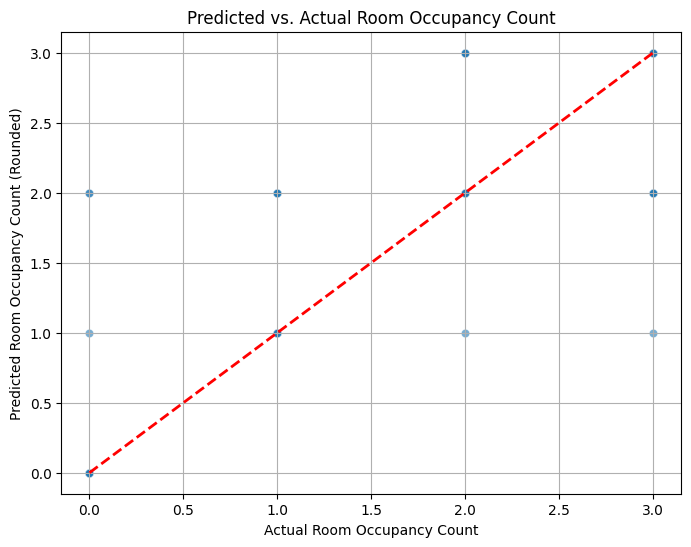

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, mean_absolute_error, mean_squared_error

# Predicted vs Actual Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_int, alpha=0.6)
plt.title('Predicted vs. Actual Room Occupancy Count')
plt.xlabel('Actual Room Occupancy Count')
plt.ylabel('Predicted Room Occupancy Count (Rounded)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
plt.grid(True)
plt.show()


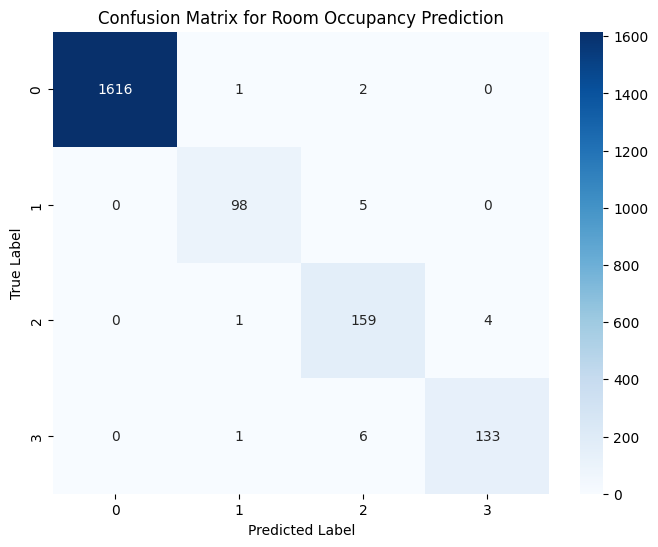

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_int)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_ if hasattr(model, 'classes_') else sorted(y_test.unique()),
            yticklabels=model.classes_ if hasattr(model, 'classes_') else sorted(y_test.unique()))
plt.title('Confusion Matrix for Room Occupancy Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
# Regression Loss Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Calculate RMSE

print(f"\nMean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")



Mean Absolute Error (MAE): 0.0142
Mean Squared Error (MSE): 0.0113
Root Mean Squared Error (RMSE): 0.1061


Convert to C Code

In [ ]:
!pip install m2cgen
import joblib, m2cgen as m2c
model = joblib.load("RFmodel.pkl")
c_code = m2c.export_to_c(model)

with open("RFmodel.c", "w") as f:
    f.write(c_code)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 9.7 MB/s eta 0:00:00
